# Task 03 – Advanced Data Analysis and Visualization in Logistics

**Objective:** Explore a simulated logistics dataset, calculate descriptive statistics and correlations, create relevant visualizations, and derive operational insights.

This notebook is designed as a complete, reproducible submission for the Advanced Data Analysis and Visualization task.


## 1. Data Simulation

The task requires a hypothetical logistics dataset. To make the analysis reproducible, the dataset is simulated using a fixed random seed. The generated records represent realistic relationships between distance, transport mode, shipment volume, delivery time, operational conditions, and logistics cost.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate a hypothetical logistics dataset
np.random.seed(42)
n = 1200

regions = np.random.choice(["North", "South", "East", "West"], n, p=[0.25, 0.25, 0.22, 0.28])
transport_modes = np.random.choice(["Road", "Rail", "Air", "Sea"], n, p=[0.55, 0.15, 0.18, 0.12])
shipment_types = np.random.choice(["Standard", "Express", "Fragile", "Bulk"], n, p=[0.42, 0.25, 0.15, 0.18])

shipment_volume = np.round(np.random.gamma(3.0, 18, n) + 5, 2)
distance_km = np.clip(np.round(np.random.lognormal(np.log(650), 0.55, n)), 80, 3000).astype(int)

speed = np.array([55 if x == "Road" else 90 if x == "Rail" else 650 if x == "Air" else 35 for x in transport_modes])
mode_delay = np.array([1.2 if x == "Road" else 0.8 if x == "Rail" else 0.4 if x == "Air" else 1.5 for x in transport_modes])

weather = np.random.choice(["Normal", "Adverse"], n, p=[0.86, 0.14])
traffic = np.random.choice(["Low", "Medium", "High"], n, p=[0.30, 0.48, 0.22])

weather_penalty = np.where(weather == "Adverse", np.random.uniform(0.5, 2.5, n), 0)
traffic_penalty = np.select(
    [traffic == "Low", traffic == "Medium", traffic == "High"],
    [0, 0.4, 1.2]
)
handling_penalty = np.where(shipment_types == "Fragile", 0.7,
                            np.where(shipment_types == "Bulk", 0.3, 0))

estimated_days = np.round(np.maximum(
    1, distance_km / speed + mode_delay + np.random.normal(0, 0.25, n)
), 2)

actual_days = np.round(np.maximum(
    1, estimated_days + traffic_penalty + weather_penalty +
    handling_penalty + np.random.normal(0, 0.8, n)
), 2)

delivery_delay = np.round(actual_days - estimated_days, 2)

cost_rate = np.array([
    1.75 if x == "Road" else 1.15 if x == "Rail" else
    4.80 if x == "Air" else 0.85 for x in transport_modes
])

transportation_cost = shipment_volume * distance_km * cost_rate / 100
handling_cost = shipment_volume * np.array([
    7 if x == "Fragile" else 4 if x == "Bulk" else 3
    for x in shipment_types
])
fuel_surcharge = transportation_cost * np.random.uniform(0.06, 0.15, n)
total_cost = np.maximum(
    transportation_cost + handling_cost + fuel_surcharge +
    np.random.normal(0, 35, n), 100
).round(2)

on_time = np.where(delivery_delay <= 0.5, "Yes", "No")
customer_rating = np.clip(
    np.round(5 - delivery_delay * 0.45 + np.random.normal(0, 0.45, n), 1),
    1, 5
)

order_dates = np.random.choice(pd.date_range("2025-01-01", "2025-12-31", freq="D"), n)

df = pd.DataFrame({
    "shipment_id": [f"SHP{100000+i}" for i in range(n)],
    "order_date": pd.to_datetime(order_dates),
    "region": regions,
    "transport_mode": transport_modes,
    "shipment_type": shipment_types,
    "shipment_volume_kg": shipment_volume,
    "distance_km": distance_km,
    "estimated_delivery_days": estimated_days,
    "actual_delivery_days": actual_days,
    "delivery_delay_days": delivery_delay,
    "transportation_cost": transportation_cost.round(2),
    "handling_cost": handling_cost.round(2),
    "fuel_surcharge": fuel_surcharge.round(2),
    "total_cost": total_cost,
    "weather_condition": weather,
    "traffic_level": traffic,
    "on_time_delivery": on_time,
    "customer_rating": customer_rating
})

df.to_csv("data/advanced_logistics_dataset.csv", index=False)

print(f"Simulated {len(df):,} shipment records.")
df.head()


Simulated 1,200 shipment records.


,shipment_id,order_date,region,transport_mode,shipment_type,shipment_volume_kg,distance_km,estimated_delivery_days,actual_delivery_days,delivery_delay_days,transportation_cost,handling_cost,fuel_surcharge,total_cost,weather_condition,traffic_level,on_time_delivery,customer_rating
0,SHP100000,2025-01-01,South,Air,Standard,59.66,601,1.31,4.29,2.98,1721.07,178.98,183.21,2117.94,Adverse,Medium,No,3.4
1,SHP100001,2025-05-08,West,Road,Standard,27.43,671,13.49,14.17,0.68,322.10,82.29,28.97,400.46,Normal,Medium,No,4.8
2,SHP100002,2025-01-01,West,Road,Standard,37.26,760,15.20,16.43,1.23,495.56,111.78,42.07,612.55,Normal,High,No,5.0
3,SHP100003,2025-06-22,East,Road,Standard,38.83,479,10.05,11.08,1.03,325.49,116.49,38.75,424.12,Normal,Medium,No,4.9
4,SHP100004,2025-09-23,North,Road,Fragile,27.30,658,12.66,13.79,1.13,314.36,191.10,22.25,541.92,Normal,Medium,No,4.2


## 1. Dataset Structure

The dataset contains shipment-level information covering order dates, regions, transport modes, shipment types, shipment volumes, distance, estimated and actual delivery time, cost components, weather, traffic, delivery performance, and customer ratings.


In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())


Shape: (1200, 18)

Data types:
shipment_id                        object
order_date                 datetime64[ns]
region                             object
transport_mode                     object
shipment_type                      object
shipment_volume_kg                float64
distance_km                         int64
estimated_delivery_days           float64
actual_delivery_days              float64
delivery_delay_days               float64
transportation_cost               float64
handling_cost                     float64
fuel_surcharge                    float64
total_cost                        float64
weather_condition                  object
traffic_level                      object
on_time_delivery                   object
customer_rating                   float64
dtype: object

Missing values:
shipment_id                0
order_date                 0
region                     0
transport_mode             0
shipment_type              0
shipment_volume_kg         0
distance

## 2. Descriptive Statistics

Central tendency and dispersion measures are used to understand the typical shipment volume, delivery time, distance, cost, delay, and customer rating.


In [3]:
numeric_cols = [
    "shipment_volume_kg", "distance_km", "estimated_delivery_days",
    "actual_delivery_days", "delivery_delay_days",
    "transportation_cost", "handling_cost", "fuel_surcharge",
    "total_cost", "customer_rating"
]

descriptive_stats = df[numeric_cols].describe().T
descriptive_stats["median"] = df[numeric_cols].median()
descriptive_stats[["count","mean","median","std","min","max"]]


,count,mean,median,std,min,max
shipment_volume_kg,1200.0,59.194658,53.670,31.605457,7.76,285.61
distance_km,1200.0,740.421667,637.000,451.628460,91.00,3000.00
estimated_delivery_days,1200.0,11.951592,10.335,9.379415,1.00,67.65
actual_delivery_days,1200.0,12.740567,11.060,9.418413,1.00,70.46
delivery_delay_days,1200.0,0.788975,0.675,1.037716,-2.76,5.42
transportation_cost,1200.0,920.262475,585.205,1030.427640,25.06,7742.88
handling_cost,1200.0,227.432217,186.730,157.284102,25.47,1197.98
fuel_surcharge,1200.0,95.395317,58.245,108.877607,2.26,1034.32
total_cost,1200.0,1244.980183,882.790,1191.258593,100.00,8929.67
customer_rating,1200.0,4.543833,4.700,0.509046,2.50,5.00


## 3. Key Performance Metrics

The main logistics KPIs are average delivery time, median delivery time, on-time delivery rate, average logistics cost, and average customer rating.


In [4]:
kpis = pd.Series({
    "Average Delivery Days": df["actual_delivery_days"].mean(),
    "Median Delivery Days": df["actual_delivery_days"].median(),
    "On-Time Delivery Rate (%)": df["on_time_delivery"].eq("Yes").mean() * 100,
    "Average Total Cost": df["total_cost"].mean(),
    "Average Customer Rating": df["customer_rating"].mean()
}).round(2)

kpis


Average Delivery Days          12.74
Median Delivery Days           11.06
On-Time Delivery Rate (%)      42.25
Average Total Cost           1244.98
Average Customer Rating         4.54
dtype: float64

## 4. Delivery Time Distribution

A histogram is appropriate because it shows the shape and spread of delivery times and helps identify whether unusually long deliveries are common.


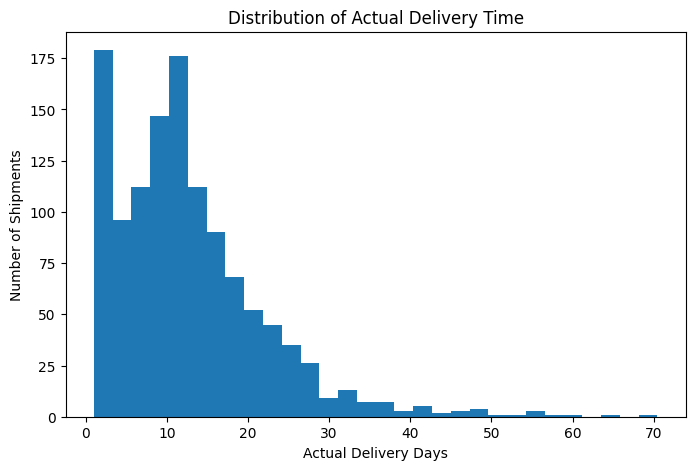

In [5]:
plt.figure(figsize=(8,5))
plt.hist(df["actual_delivery_days"], bins=30)
plt.title("Distribution of Actual Delivery Time")
plt.xlabel("Actual Delivery Days")
plt.ylabel("Number of Shipments")
plt.show()


## 5. Monthly Shipment Volume

A line chart is used to show how shipment volume changes over time and to identify seasonal peaks or periods of lower activity.


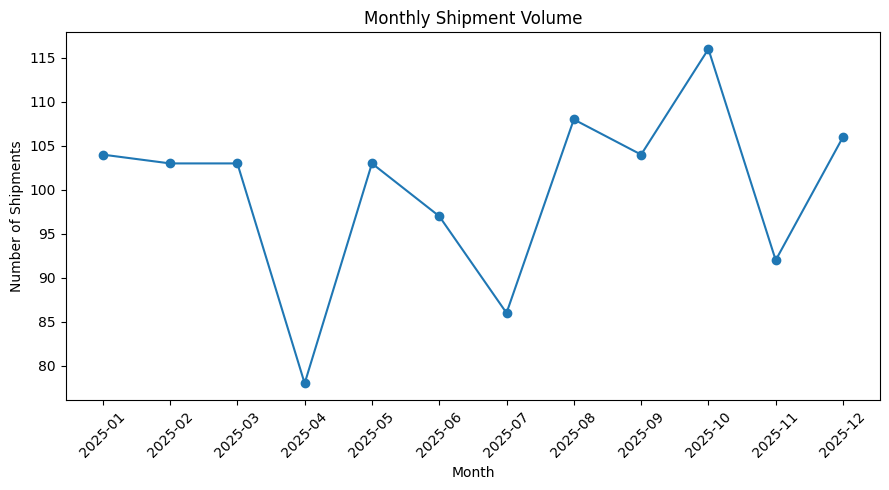

In [6]:
monthly_volume = df.groupby(df["order_date"].dt.to_period("M"))["shipment_id"].count()
monthly_volume.index = monthly_volume.index.astype(str)

plt.figure(figsize=(9,5))
plt.plot(monthly_volume.index, monthly_volume.values, marker="o")
plt.title("Monthly Shipment Volume")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Cost by Transport Mode

A bar chart is used to compare average total logistics cost across transport modes. This makes differences between categorical groups easy to interpret.


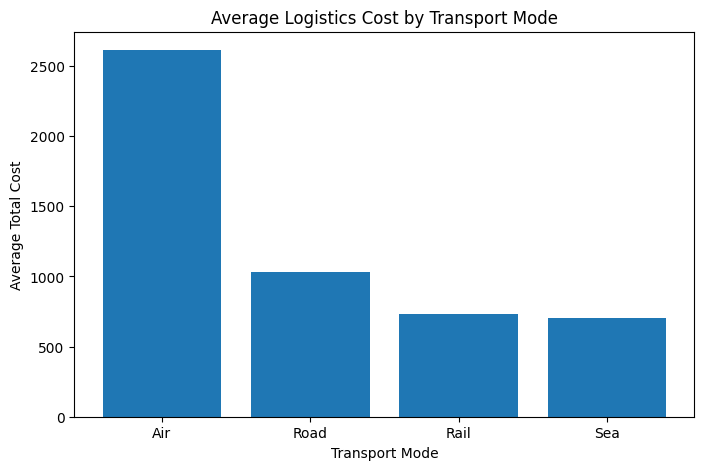

In [7]:
mode_cost = df.groupby("transport_mode")["total_cost"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(mode_cost.index, mode_cost.values)
plt.title("Average Logistics Cost by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Total Cost")
plt.show()


## 7. On-Time Delivery by Region

Regional performance is compared using on-time delivery percentage. This helps identify geographic areas where operational improvements may be required.


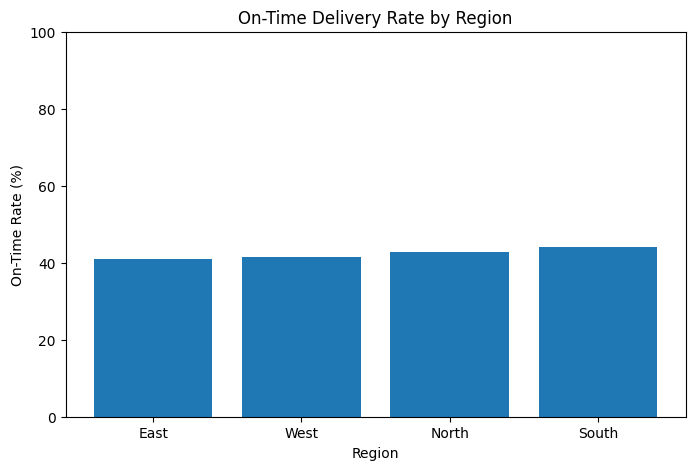

In [8]:
region_ontime = (
    df.groupby("region")["on_time_delivery"]
      .apply(lambda x: x.eq("Yes").mean() * 100)
      .sort_values()
)

plt.figure(figsize=(8,5))
plt.bar(region_ontime.index, region_ontime.values)
plt.title("On-Time Delivery Rate by Region")
plt.xlabel("Region")
plt.ylabel("On-Time Rate (%)")
plt.ylim(0, 100)
plt.show()


## 8. Distance and Cost Relationship

A scatter plot is appropriate for examining the relationship between two continuous variables. Distance is expected to be an important cost driver because longer routes require more transportation resources.


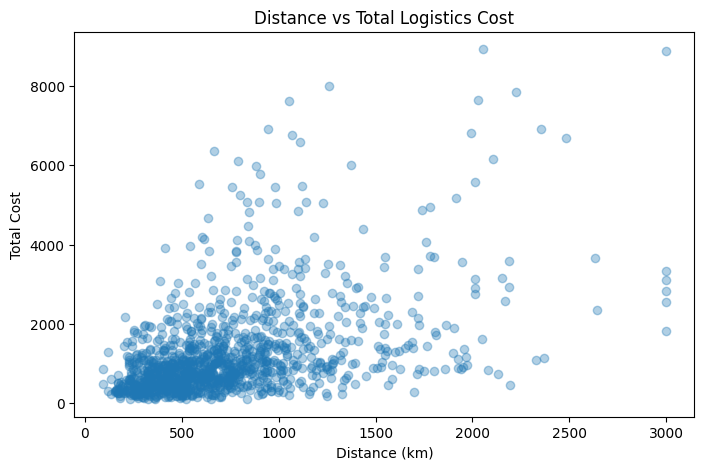

Correlation between distance and total cost: 0.473


In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["distance_km"], df["total_cost"], alpha=0.35)
plt.title("Distance vs Total Logistics Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Total Cost")
plt.show()

print("Correlation between distance and total cost:",
      round(df["distance_km"].corr(df["total_cost"]), 3))


## 9. Correlation Analysis

Correlation analysis helps identify relationships between numerical logistics metrics. It can highlight potential cost drivers and variables associated with delivery delays.


In [10]:
corr_cols = [
    "shipment_volume_kg", "distance_km", "estimated_delivery_days",
    "actual_delivery_days", "delivery_delay_days",
    "transportation_cost", "handling_cost", "fuel_surcharge",
    "total_cost", "customer_rating"
]

corr = df[corr_cols].corr().round(2)
corr


,shipment_volume_kg,distance_km,estimated_delivery_days,actual_delivery_days,delivery_delay_days,transportation_cost,handling_cost,fuel_surcharge,total_cost,customer_rating
shipment_volume_kg,1.00,-0.07,-0.01,-0.00,0.06,0.41,0.78,0.39,0.49,-0.03
distance_km,-0.07,1.00,0.63,0.62,-0.03,0.51,-0.08,0.49,0.47,0.04
estimated_delivery_days,-0.01,0.63,1.00,0.99,-0.02,-0.06,-0.03,-0.05,-0.06,0.05
actual_delivery_days,-0.00,0.62,0.99,1.00,0.09,-0.06,-0.01,-0.05,-0.06,-0.03
delivery_delay_days,0.06,-0.03,-0.02,0.09,1.00,0.02,0.17,0.02,0.04,-0.69
transportation_cost,0.41,0.51,-0.06,-0.06,0.02,1.00,0.30,0.94,0.99,-0.02
handling_cost,0.78,-0.08,-0.03,-0.01,0.17,0.30,1.00,0.30,0.43,-0.10
fuel_surcharge,0.39,0.49,-0.05,-0.05,0.02,0.94,0.30,1.00,0.95,-0.03
total_cost,0.49,0.47,-0.06,-0.06,0.04,0.99,0.43,0.95,1.00,-0.03
customer_rating,-0.03,0.04,0.05,-0.03,-0.69,-0.02,-0.10,-0.03,-0.03,1.00


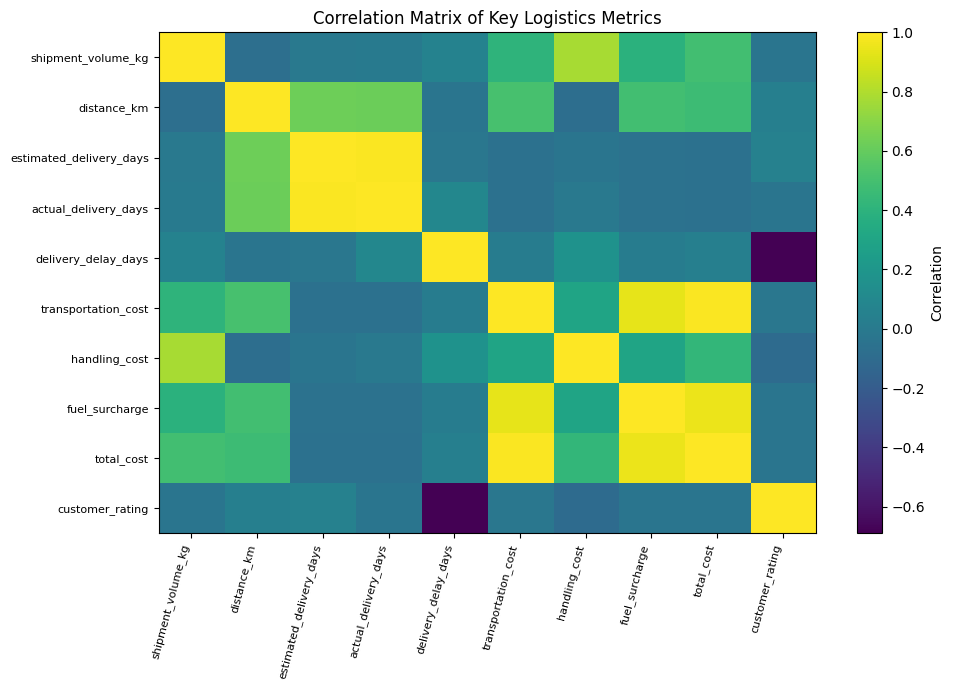

In [11]:
plt.figure(figsize=(10,7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=75, ha="right", fontsize=8)
plt.yticks(range(len(corr_cols)), corr_cols, fontsize=8)
plt.title("Correlation Matrix of Key Logistics Metrics")
plt.tight_layout()
plt.show()


## 10. Analytical Insights

1. **Delivery performance:** The on-time delivery KPI provides a direct measure of service reliability. Shipments exceeding the estimated delivery time should be investigated for recurring operational causes.

2. **Cost drivers:** Distance and shipment volume have a strong operational relationship with transportation cost. Long-distance and high-volume shipments require greater resource allocation.

3. **Transport mode:** Average cost varies considerably by transport mode. Air shipments generally provide speed but carry a higher cost, while slower modes can be more economical for suitable shipments.

4. **Regional bottlenecks:** Differences in regional on-time rates can indicate route, traffic, capacity, or operational issues that require targeted investigation.

5. **Customer experience:** Delivery delays are associated with lower customer ratings, showing why improving delivery reliability can have benefits beyond internal efficiency.

6. **Decision-making:** Combining cost, delivery time, and on-time performance provides a better basis for logistics decisions than evaluating any single KPI independently.


## 11. Recommendations

- Prioritize investigation of regions with comparatively lower on-time delivery performance.
- Review high-cost transport routes and evaluate whether alternative modes are operationally feasible.
- Monitor long-distance and high-volume shipments more closely because they have greater cost exposure.
- Use delivery-delay analysis as an early warning KPI for customer experience deterioration.
- Build a recurring logistics dashboard combining shipment volume, delivery time, cost, and service-level metrics.


## Conclusion

The analysis demonstrates how simulated logistics data can be transformed into actionable operational insights using Python. Descriptive statistics establish the baseline, visualizations reveal trends and relationships, and correlation analysis helps identify important variables. Together, these techniques support data-driven decisions around delivery reliability, cost management, and operational efficiency.
